# Лабораторная работа №5
## Сравнение RNN и LSTM на задаче анализа тональности (IMDb)

In [ ]:
# Установка необходимых библиотек
!pip install tensorflow datasets scikit-learn matplotlib seaborn pandas

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("TensorFlow version:", tf.__version__)

## 1. Загрузка датасета IMDb

In [ ]:
# Загружаем датасет IMDb через HuggingFace datasets
# Датасет содержит 50 000 отзывов на фильмы: 25 000 train + 25 000 test
# Каждый отзыв имеет метку: 0 = негативный, 1 = позитивный
from datasets import load_dataset

dataset = load_dataset("imdb")

print("Размер обучающей выборки:", len(dataset['train']))
print("Размер тестовой выборки:", len(dataset['test']))
print()

# Пример текста и его метки
example = dataset['train'][0]
label_name = "позитивный" if example['label'] == 1 else "негативный"
print(f"Метка: {example['label']} ({label_name})")
print(f"Текст (первые 300 символов):\n{example['text'][:300]}...")
print()

# Распределение классов в обучающей выборке
# IMDb — сбалансированный датасет: ровно по 12 500 примеров каждого класса
# Это значит, что метрика Accuracy здесь будет надёжным показателем качества
train_labels = np.array(dataset['train']['label'])
unique, counts = np.unique(train_labels, return_counts=True)
for label, count in zip(unique, counts):
    name = "позитивных" if label == 1 else "негативных"
    print(f"Класс {label} ({name}): {count} примеров ({count/len(train_labels)*100:.1f}%)")

In [ ]:
dataset['train']['text'][0]

'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, ev

## 2. Токенизация и построение словаря

In [ ]:
# Извлекаем тексты и метки из датасета
train_texts = dataset['train']['text']
test_texts = dataset['test']['text']
y_train = np.array(dataset['train']['label'])
y_test = np.array(dataset['test']['label'])

# Очистка текстов от HTML-тегов (IMDb содержит <br />, <p> и т.д.)
# Без очистки HTML-теги становятся бесполезными токенами и занимают место в словаре
def clean_html(text):
    """Удаляет HTML-теги из текста."""
    return re.sub(r'<[^>]+>', ' ', text)

train_texts = [clean_html(t) for t in train_texts]
test_texts = [clean_html(t) for t in test_texts]

print(f"Пример очищенного текста (первые 200 символов):\n{train_texts[0][:200]}...")
print()

# Создаём токенизатор Keras
# num_words=25000 — ограничиваем словарь 25 000 самых частых слов.
# Почему не берём все? Редкие слова встречаются 1-2 раза и не несут статистически
# значимой информации, зато увеличивают размер Embedding-матрицы и замедляют обучение.
# oov_token="<OOV>" — специальный токен для слов, не вошедших в словарь (Out-Of-Vocabulary).
# Без него неизвестные слова просто исчезнут из последовательности, с ним — заменяются
# на индекс 1, и модель хотя бы «знает», что тут было неизвестное слово.
tokenizer = Tokenizer(num_words=25000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

# Переводим тексты в последовательности индексов
train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

print(f"Размер словаря (всего уникальных слов): {len(tokenizer.word_index)}")
print(f"Используем топ-25000 слов")

Пример очищенного текста (первые 200 символов):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...

Размер словаря (всего уникальных слов): 88577
Используем топ-25000 слов


In [ ]:
# Паддинг — выравнивание всех последовательностей до одинаковой длины.
# Зачем? RNN/LSTM обрабатывают батчи, а батч — это матрица фиксированного размера.
# Все отзывы должны иметь одинаковую длину.
# maxlen=500 — длина последовательности. Средний отзыв IMDb ~230 слов,
# но многие длиннее — 500 токенов захватывает основную часть информации.
# padding='pre' — нули добавляются в начало (перед текстом).
# Это важно для RNN/LSTM: последнее скрытое состояние h_T формируется на реальных словах.
# truncating='post' — если отзыв длиннее 500 токенов, обрезаем конец.
MAXLEN = 500

X_train = pad_sequences(train_sequences, maxlen=MAXLEN, padding='pre', truncating='post')
X_test = pad_sequences(test_sequences, maxlen=MAXLEN, padding='pre', truncating='post')

print(f"Форма X_train после паддинга: {X_train.shape}")
print(f"Форма X_test после паддинга:  {X_test.shape}")
print()

# Пример: первый отзыв в виде индексов (первые 20 токенов — скорее всего нули паддинга)
print("Первый отзыв (первые 20 токенов):", X_train[0][:20])
# Последние 20 токенов — реальные слова
print("Первый отзыв (последние 20 токенов):", X_train[0][-20:])

Форма X_train после паддинга: (25000, 500)
Форма X_test после паддинга:  (25000, 500)

Первый отзыв (первые 20 токенов): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Первый отзыв (последние 20 токенов): [    2  3536     3 17633    54  5229  1433     5  3899   434    18    63
    11    19   149    25    73     5     4   111]


## 3. Модель RNN

In [ ]:
# Строим простую рекуррентную нейронную сеть (SimpleRNN)
# Архитектура: Embedding -> SimpleRNN -> Dropout -> Dense -> Dense(sigmoid)
rnn_model = keras.Sequential([
    # Embedding — превращает индексы слов в плотные векторы размерности 128.
    # Это гораздо эффективнее one-hot кодирования: вместо разреженного вектора
    # длиной 25000 (где только одна единица) получаем компактный вектор из 128 чисел.
    # При этом семантически близкие слова получают близкие векторы.
    # input_dim=25000 — размер словаря, output_dim=128 — размерность эмбеддинга.
    # mask_zero=True — КЛЮЧЕВОЙ параметр: говорит RNN/LSTM полностью игнорировать
    # нулевые токены (паддинг). Без него модель обрабатывает сотни нулей как реальные
    # слова, что «размывает» скрытое состояние и убивает качество.
    layers.Embedding(input_dim=25000, output_dim=128, mask_zero=True),

    # SimpleRNN — базовая рекуррентная ячейка с 64 нейронами.
    # На каждом шаге получает текущий токен и скрытое состояние с предыдущего шага:
    # h_t = tanh(W_h * h_{t-1} + W_x * x_t + b)
    # return_sequences=False — возвращаем только последнее скрытое состояние (h_T),
    # а не всю последовательность. True нужен, когда следующий слой тоже рекуррентный
    # и ожидает последовательность на входе.
    layers.SimpleRNN(64, return_sequences=False),

    # Dropout — случайно «выключает» 50% нейронов при обучении.
    # Это регуляризация: предотвращает переобучение и улучшает обобщение.
    layers.Dropout(0.5),

    # Полносвязный слой для извлечения признаков из скрытого состояния
    layers.Dense(64, activation='relu'),

    # Выходной слой: 1 нейрон с sigmoid — выдаёт вероятность от 0 до 1.
    # sigmoid используется вместо softmax, потому что у нас бинарная классификация
    # (позитивный/негативный), а не многоклассовая.
    layers.Dense(1, activation='sigmoid')
])

# Компиляция модели:
# - optimizer='adam' — адаптивный оптимизатор, подстраивает learning rate
# - loss='binary_crossentropy' — функция потерь для бинарной классификации.
#   Используем binary, а не categorical, потому что у нас один выходной нейрон
#   с sigmoid, а не два нейрона с softmax.
# - metrics=['accuracy'] — отслеживаем точность
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Обучаем RNN
# epochs=7 — количество полных проходов по обучающей выборке
# batch_size=128 — размер мини-батча
# validation_split=0.1 — 10% обучающих данных откладываем для валидации
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=7,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/7
176/176 ━━━━━━━━━━━━━━━━━━━━ 83s 454ms/step - accuracy: 0.5678 - loss: 0.6806 - val_accuracy: 0.6924 - val_loss: 0.6215
Epoch 2/7
176/176 ━━━━━━━━━━━━━━━━━━━━ 80s 455ms/step - accuracy: 0.7330 - loss: 0.5379 - val_accuracy: 0.4000 - val_loss: 1.1326
Epoch 3/7
176/176 ━━━━━━━━━━━━━━━━━━━━ 80s 453ms/step - accuracy: 0.7706 - loss: 0.4803 - val_accuracy: 0.8244 - val_loss: 0.4437
Epoch 4/7
176/176 ━━━━━━━━━━━━━━━━━━━━ 80s 452ms/step - accuracy: 0.7539 - loss: 0.4969 - val_accuracy: 0.6072 - val_loss: 0.6817
Epoch 5/7
176/176 ━━━━━━━━━━━━━━━━━━━━ 80s 455ms/step - accuracy: 0.8331 - loss: 0.3881 - val_accuracy: 0.7280 - val_loss: 0.5772
Epoch 6/7
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 458ms/step - accuracy: 0.8795 - loss: 0.3018 - val_accuracy: 0.7588 - val_loss: 0.6155
Epoch 7/7
176/176 ━━━━━━━━━━━━━━━━━━━━ 82s 457ms/step - accuracy: 0.9083 - loss: 0.2432 - val_accuracy: 0.7872 - val_loss: 0.5356


## 4. Модель LSTM

**Почему LSTM лучше справляется с длинными последовательностями?**

Обычная RNN страдает от проблемы **затухающего градиента**: при обратном распространении ошибки через много временных шагов градиенты умножаются на одни и те же весовые матрицы и экспоненциально уменьшаются. Из-за этого RNN практически «забывает» информацию из далёких токенов.

LSTM (Long Short-Term Memory) решает эту проблему с помощью **трёх гейтов** и отдельного **cell state** (состояния ячейки):

- **Forget gate** (гейт забывания) — решает, какую часть старой информации из cell state стереть
- **Input gate** (входной гейт) — решает, какую новую информацию записать в cell state
- **Output gate** (выходной гейт) — решает, какую часть cell state выдать как скрытое состояние

Благодаря cell state информация может передаваться через сотни шагов практически без потерь — это «транспортёр памяти» LSTM.

In [ ]:
# Строим LSTM-модель — архитектура идентична RNN,
# единственное отличие: SimpleRNN(64) заменён на LSTM(64).
# Все остальные параметры (Embedding, Dense, Dropout, optimizer, loss, epochs, batch_size)
# оставляем такими же — для честного сравнения двух архитектур.
lstm_model = keras.Sequential([
    layers.Embedding(input_dim=25000, output_dim=128, mask_zero=True),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Те же параметры компиляции, что и у RNN — для честного сравнения
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Обучаем LSTM с теми же параметрами, что и RNN
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.7749 - loss: 0.4530 - val_accuracy: 0.8812 - val_loss: 0.3121
Epoch 2/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.9123 - loss: 0.2479 - val_accuracy: 0.8732 - val_loss: 0.3030
Epoch 3/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.9502 - loss: 0.1465 - val_accuracy: 0.7872 - val_loss: 0.6948


## 5. Графики функции потерь и точности

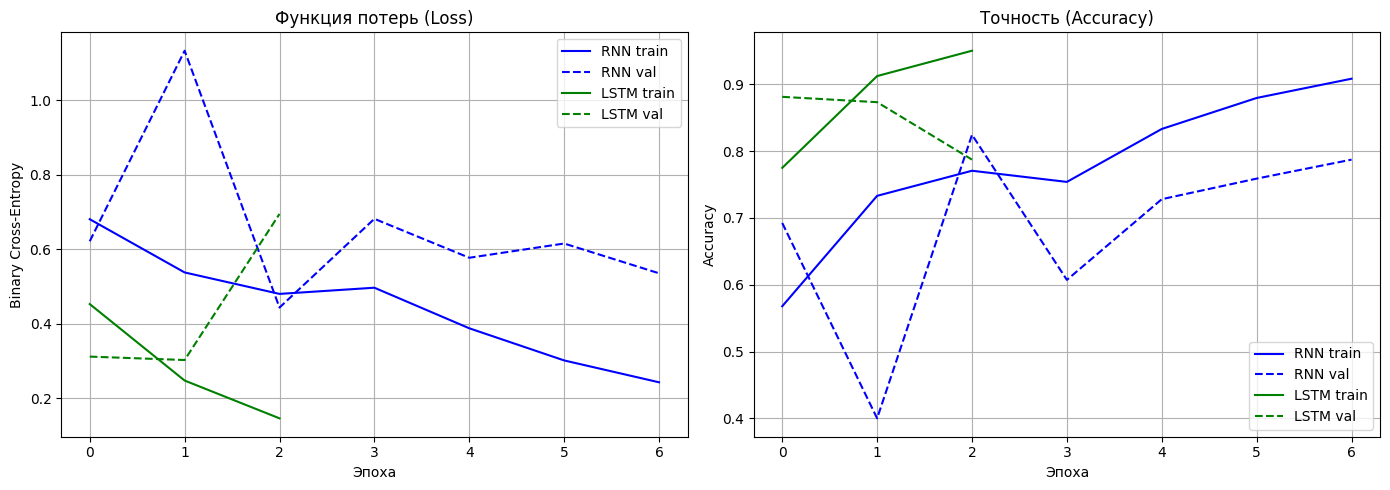

In [ ]:
# Графики loss и accuracy обеих моделей на одном рисунке
# RNN — синий, LSTM — зелёный; train — сплошная, val — пунктир
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Левый график: Loss ---
axes[0].plot(rnn_history.history['loss'], color='blue', linestyle='-', label='RNN train')
axes[0].plot(rnn_history.history['val_loss'], color='blue', linestyle='--', label='RNN val')
axes[0].plot(lstm_history.history['loss'], color='green', linestyle='-', label='LSTM train')
axes[0].plot(lstm_history.history['val_loss'], color='green', linestyle='--', label='LSTM val')
axes[0].set_title('Функция потерь (Loss)')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Binary Cross-Entropy')
axes[0].legend()
axes[0].grid(True)

# --- Правый график: Accuracy ---
axes[1].plot(rnn_history.history['accuracy'], color='blue', linestyle='-', label='RNN train')
axes[1].plot(rnn_history.history['val_accuracy'], color='blue', linestyle='--', label='RNN val')
axes[1].plot(lstm_history.history['accuracy'], color='green', linestyle='-', label='LSTM train')
axes[1].plot(lstm_history.history['val_accuracy'], color='green', linestyle='--', label='LSTM val')
axes[1].set_title('Точность (Accuracy)')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Метрики и сравнение

In [ ]:
# Получаем предсказания обеих моделей на тестовой выборке
# sigmoid выдаёт вероятность, порог 0.5 превращает её в класс 0 или 1
y_pred_rnn = (rnn_model.predict(X_test) > 0.5).astype(int).flatten()
y_pred_lstm = (lstm_model.predict(X_test) > 0.5).astype(int).flatten()

782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 97ms/step


In [ ]:
def compute_metrics(y_true, y_pred, model_name):
    """Вычисляет и выводит основные метрики бинарной классификации.

    Параметры:
        y_true — истинные метки
        y_pred — предсказанные метки
        model_name — название модели для вывода

    Возвращает:
        dict с метриками Accuracy, Precision, Recall, F1
    """
    acc = accuracy_score(y_true, y_pred)
    # average='binary' — метрики для бинарной классификации (позитивный класс = 1)
    prec = precision_score(y_true, y_pred, average='binary')
    rec = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')

    print(f"=== {model_name} ===")
    print(f"Accuracy  (доля правильных): {acc:.4f}")
    print(f"Precision (точность):        {prec:.4f}")
    print(f"Recall    (полнота):          {rec:.4f}")
    print(f"F1-score  (гармоническое среднее P и R): {f1:.4f}")
    print()

    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}


rnn_metrics = compute_metrics(y_test, y_pred_rnn, "RNN")
lstm_metrics = compute_metrics(y_test, y_pred_lstm, "LSTM")

=== RNN ===
Accuracy  (доля правильных): 0.8066
Precision (точность):        0.8178
Recall    (полнота):          0.7890
F1-score  (гармоническое среднее P и R): 0.8031

=== LSTM ===
Accuracy  (доля правильных): 0.8598
Precision (точность):        0.9030
Recall    (полнота):          0.8062
F1-score  (гармоническое среднее P и R): 0.8519



In [ ]:
# Детальный classification report для обеих моделей
print("=== RNN — Classification Report ===")
print(classification_report(y_test, y_pred_rnn, target_names=['Негативный', 'Позитивный']))

print("\n=== LSTM — Classification Report ===")
print(classification_report(y_test, y_pred_lstm, target_names=['Негативный', 'Позитивный']))

=== RNN — Classification Report ===
              precision    recall  f1-score   support

  Негативный       0.80      0.82      0.81     12500
  Позитивный       0.82      0.79      0.80     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000


=== LSTM — Classification Report ===
              precision    recall  f1-score   support

  Негативный       0.82      0.91      0.87     12500
  Позитивный       0.90      0.81      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [ ]:
# Сравнительная таблица метрик
comparison = pd.DataFrame({
    'RNN': rnn_metrics,
    'LSTM': lstm_metrics
}).T  # транспонируем для удобного отображения

print("=== Сравнение моделей ===")
print(comparison.to_string())
print()

# Программный вывод: определяем лучшую модель по F1-score
if lstm_metrics['F1'] > rnn_metrics['F1']:
    print("Вывод: LSTM показывает лучшие результаты, чем SimpleRNN.")
    print("Это ожидаемо: LSTM благодаря механизму гейтов и cell state")
    print("лучше улавливает долгосрочные зависимости в тексте отзывов.")
    print("Например, отрицание в начале предложения может менять смысл")
    print("слов в конце — RNN часто 'забывает' такие связи.")
elif rnn_metrics['F1'] > lstm_metrics['F1']:
    print("Вывод: SimpleRNN показал результаты не хуже LSTM.")
    print("Это может объясняться тем, что для определения тональности")
    print("часто достаточно коротких локальных паттернов ('отличный фильм',")
    print("'ужасная игра'), и сложный механизм памяти LSTM не даёт преимущества.")
else:
    print("Вывод: обе модели показали одинаковый F1-score.")

=== Сравнение моделей ===
      Accuracy  Precision   Recall        F1
RNN    0.80660   0.817760  0.78904  0.803143
LSTM   0.85984   0.903047  0.80624  0.851902

Вывод: LSTM показывает лучшие результаты, чем SimpleRNN.
Это ожидаемо: LSTM благодаря механизму гейтов и cell state
лучше улавливает долгосрочные зависимости в тексте отзывов.
Например, отрицание в начале предложения может менять смысл
слов в конце — RNN часто 'забывает' такие связи.


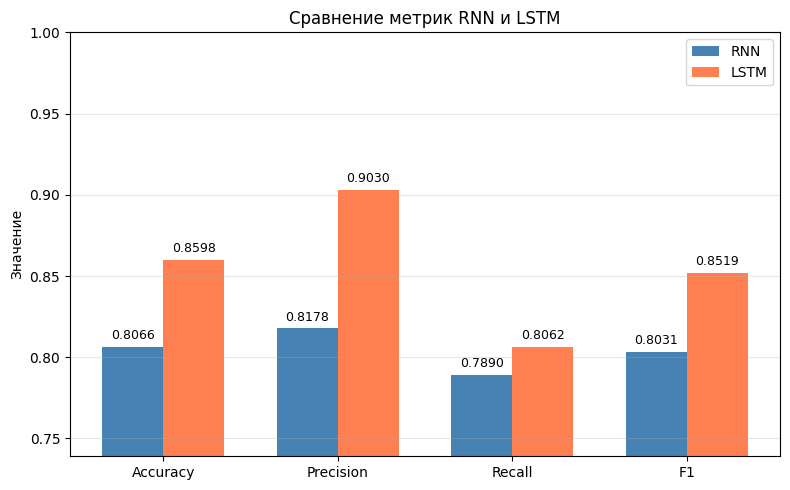

In [ ]:
metrics_names = list(rnn_metrics.keys())
rnn_values = list(rnn_metrics.values())
lstm_values = list(lstm_metrics.values())

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, rnn_values, width, label='RNN', color='steelblue')
bars2 = ax.bar(x + width/2, lstm_values, width, label='LSTM', color='coral')

ax.set_ylabel('Значение')
ax.set_title('Сравнение метрик RNN и LSTM')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
# Подбираем ylim так, чтобы различия были видны
all_values = rnn_values + lstm_values
ax.set_ylim(min(all_values) - 0.05, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Подписи значений на столбцах
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Предсказания на отдельных отзывах

In [ ]:
# Выбираем 3 случайных отзыва из тестовой выборки
np.random.seed(553)
indices = np.random.choice(len(X_test), 3, replace=False)

# Обратный словарь: индекс → слово (для декодирования последовательностей обратно в текст)
reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}

for row, idx in enumerate(indices):
    true_label = y_test[idx]
    label_name = "Позитивный" if true_label == 1 else "Негативный"

    # Декодируем отзыв обратно в текст (пропускаем нули паддинга и OOV)
    decoded = ' '.join([reverse_word_index.get(i, '') for i in X_test[idx] if i != 0])
    # Показываем первые 200 символов отзыва
    preview = decoded[:200] + ('...' if len(decoded) > 200 else '')
    print(f"{'='*70}")
    print(f"Отзыв #{row+1} (индекс {idx}) | Истинная метка: {true_label} ({label_name})")
    print(f"{'─'*70}")
    print(f"  Текст: {preview}")
    print()

    # Предсказания (вероятность позитивного класса от sigmoid)
    rnn_prob = rnn_model.predict(X_test[idx:idx+1], verbose=0)[0][0]
    lstm_prob = lstm_model.predict(X_test[idx:idx+1], verbose=0)[0][0]

    rnn_pred = int(rnn_prob > 0.5)
    lstm_pred = int(lstm_prob > 0.5)

    status_rnn = "ВЕРНО" if rnn_pred == true_label else "ОШИБКА"
    status_lstm = "ВЕРНО" if lstm_pred == true_label else "ОШИБКА"

    rnn_pred_name = "Позитивный" if rnn_pred == 1 else "Негативный"
    lstm_pred_name = "Позитивный" if lstm_pred == 1 else "Негативный"

    print(f"  {'Модель':<8} {'Предсказание':<16} {'P(позитивный)':>16} {'Результат':>12}")
    print(f"  {'─'*56}")
    print(f"  {'RNN':<8} {rnn_pred_name:<16} {rnn_prob:>16.4f} {status_rnn:>12}")
    print(f"  {'LSTM':<8} {lstm_pred_name:<16} {lstm_prob:>16.4f} {status_lstm:>12}")
    print()

Отзыв #1 (индекс 9488) | Истинная метка: 0 (Негативный)
──────────────────────────────────────────────────────────────────────
  Текст: seems like a pretty innocent choice at first the name employee of the month might ring bells with office space and the show office clerk i think not this isn't even a dark comedy the director of this ...

  Модель   Предсказание        P(позитивный)    Результат
  ────────────────────────────────────────────────────────
  RNN      Негативный                 0.1718        ВЕРНО
  LSTM     Негативный                 0.0511        ВЕРНО

Отзыв #2 (индекс 6561) | Истинная метка: 0 (Негативный)
──────────────────────────────────────────────────────────────────────
  Текст: carrot top in a full length movie enough said only reason this doesn't get a one is through my personal voting system of only one 1 and one 10 and this is no extreme ops horrible god awful there are s...

  Модель   Предсказание        P(позитивный)    Результат
  ────────────────────────

In [ ]:
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
import re

dataset = load_dataset('imdb')
texts = [re.sub(r'<[^>]+>', ' ', t) for t in dataset['train']['text']]
tokenizer = Tokenizer(num_words=25000, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
seqs = tokenizer.texts_to_sequences(texts)
lengths = [len(s) for s in seqs]
total = len(lengths)
fit = sum(1 for l in lengths if l <= 500)
print(f'Отзывов <= 500 токенов: {fit}/{total} ({fit/total*100:.1f}%)')
print(f'Средняя длина: {sum(lengths)/total:.0f} токенов')
print(f'Макс длина: {max(lengths)} токенов')

Отзывов <= 500 токенов: 22999/25000 (92.0%)
Средняя длина: 234 токенов
Макс длина: 2473 токенов
